# Momentum Strategy

1. Define Momentum Conditions:

* Price Movement: Use Rate of Change (ROC) or Moving Average crossovers as your momentum entry signal. (Positive ROC suggests bullish momentum.)

* Volatility Filter: Use ATR to confirm strong volatility (momentum). You don’t want to trade in low volatility periods. (ATR rising suggests increasing volatility and strong price movement.)

* Directional Confirmation: Use DMI or MACD to confirm that momentum is strong in one direction. (+DI > -DI indicates an ongoing bullish trend (and vice versa for bearish momentum).)

2. Risk Management:

* Use a fixed percentage of your capital per trade (e.g., 1–2% per trade).

* Implement a stop loss based on volatility (using ATR or a fixed percentage).

* Implement a take-profit level or trailing stop to capture the trend’s full potential.

3. Position Sizing:

* Risk-based sizing: The position size should scale with volatility. Use ATR to determine how large a position to take based on the current volatility.

For example, larger ATR means higher risk, so you reduce position size.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from utils.read_prices import read_parquet
from utils.metrics import Metrics as m
import talib

In [3]:
df = read_parquet()
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


In [4]:
amount = 5000

# 1/2 * df['Close'].loc['2016-01-01'].item()
units = 500 / df['Close'].loc['2016-01-01'].item()

amount -= (units * df['Close'].loc['2016-01-01'].item()) * (1 + .0015) + (.0036)

amount 

4499.2464

In [5]:
df['roc'] = talib.ROC(df['Close'], 1)
df['atr'] = talib.ATR(df['High'], df['Low'], df['Close'])
df['di+'] = talib.PLUS_DI(df['High'], df['Low'], df['Close'])
df['di-'] = talib.MINUS_DI(df['High'], df['Low'], df['Close'])

In [ ]:
# talib.ATR(df['High'], df['Low'], df['Close']).iloc[-2]

np.float64(1256.6064131118796)

In [7]:
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,roc,atr,di+,di-
Date,,,,,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065,-0.206299,NaN,NaN,NaN
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938,-0.790656,NaN,NaN,NaN
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137,0.716265,NaN,NaN,NaN
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615,-0.261149,NaN,NaN,NaN


<Axes: xlabel='Date'>

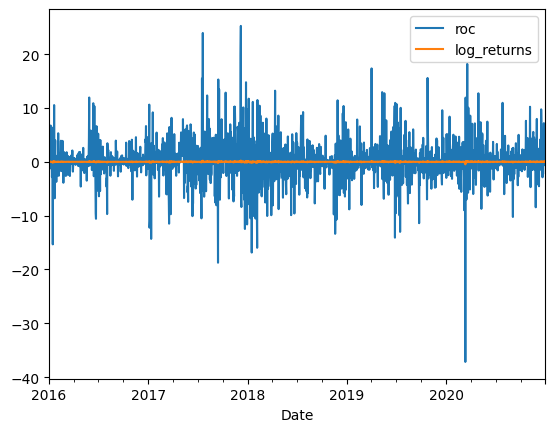

In [8]:
df[['roc', 'log_returns']].plot()

In [9]:
'''
Most simple time series momentum strategy where you buy the stock if the last return was positive and sell the stock if the sign was negative.
'''

strat_1 = df['log_returns'] * np.sign(df['roc']).shift(1)
strat_2 = df['log_returns'] * np.sign(df['log_returns']).shift(1)

In [10]:
df_ = df.copy().dropna()

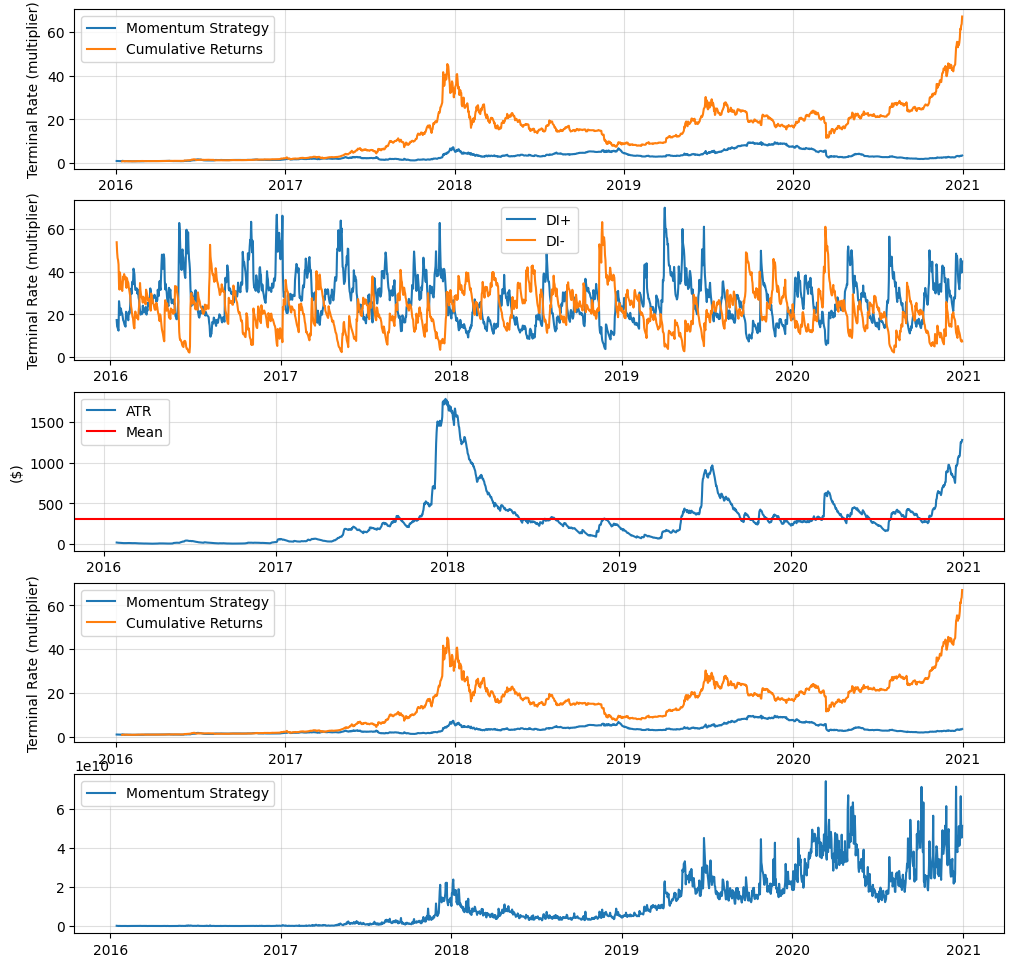

In [11]:
fig, ax = plt.subplots(5, 1, figsize=(12,12))

atr = talib.ATR(df_['High'], df_['Low'], df_['Close'])
# dmi = talib.MACD()

ax[0].plot(np.exp(strat_1.cumsum()), label='Momentum Strategy')
ax[0].plot(np.exp(df_['log_returns'].cumsum()), label='Cumulative Returns')
ax[0].grid(alpha=.4)
ax[0].set_ylabel('Terminal Rate (multiplier)')
ax[0].legend()

ax[1].plot(df_['di+'], label='DI+')
ax[1].plot(df_['di-'], label='DI-')
ax[1].grid(alpha=.4)
ax[1].set_ylabel('Terminal Rate (multiplier)')
ax[1].legend()

ax[2].plot(atr, label='ATR')
ax[2].axhline(atr.mean(), label='Mean', c='r')
ax[2].set_ylabel('($)')
ax[2].grid(alpha=.4)
ax[2].legend()

ax[3].plot(np.exp(strat_2.cumsum()), label='Momentum Strategy')
ax[3].plot(np.exp(df_['log_returns'].cumsum()), label='Cumulative Returns')
ax[3].set_ylabel('Terminal Rate (multiplier)')
ax[3].grid(alpha=.4)
ax[3].legend()

ax[4].plot(df_['Volume'], label='Momentum Strategy')
ax[4].set_ylabel('')
ax[4].grid(alpha=.4)
ax[4].legend()

plt.show()

Using both the log returns and the roc from the close price we can see that they perform about as well as one another. Going forward we will continue to use the sign of the change in the log returns as our entry signal into the market.

In [12]:
momentum_term_ret = m.terminal_return(strat_2)
cum_returns = m.terminal_return(df['log_returns'])

print(f"Terminal return of momentum strategy: {momentum_term_ret*100:.2f} %")
print(f"Terminal return of asset: {cum_returns*100:.2f} %")

Terminal return of momentum strategy: 251.73 %
Terminal return of asset: 6540.27 %


### Advanced Strategy using di- +/-

In [13]:
(strat_2 > 0).sum()

np.int64(879)

In [14]:
df_[(strat_2 > 0) & (df_['di+'] > df_['di-']) & (df_['atr'] > df_['atr'].mean())].shape[0]

/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_24667/3625691189.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_[(strat_2 > 0) & (df_['di+'] > df_['di-']) & (df_['atr'] > df_['atr'].mean())].shape[0]


180

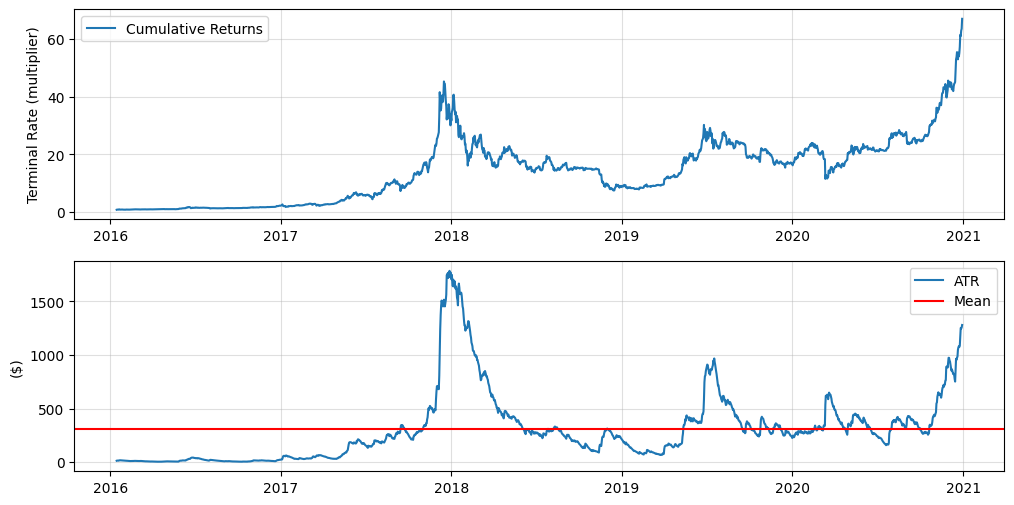

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(12,6))

atr = talib.ATR(df['High'], df['Low'], df['Close'])

# ax[0].plot(np.exp(adv_signal.cumsum()), label='Momentum Strategy')
ax[0].plot(np.exp(df_['log_returns'].cumsum()), label='Cumulative Returns')
ax[0].grid(alpha=.4)
ax[0].set_ylabel('Terminal Rate (multiplier)')
ax[0].legend()

ax[1].plot(atr, label='ATR')
ax[1].axhline(atr.mean(), label='Mean', c='r')
ax[1].set_ylabel('($)')
ax[1].grid(alpha=.4)
ax[1].legend()

In [16]:
adv_signal_term_return = m.terminal_return(adv_signal)

print(f"Terminal Return using advnaced trading strategy: {adv_signal_term_return*100:.2f} %")

NameError: name 'adv_signal' is not defined

In [ ]:
# adv_signal = (strat_2 > 0) & (df_['di+'] > df_['di-'])
# adv_signal = df_['log_returns'] * adv_signal

position = 0
momentum_sign = np.sign(df_['log_returns'].rolling(3).mean())
strat_2 = df_['log_returns'] * momentum_sign

# for bar in range(3, len(df_)):
#     if position == 0:
#         ## long signal
#         if strat_2 > 0:
#             # enter long position
#             if df_['di+'] > df_['di-'] and df_['atr'] > df_['atr'].mean():
# #               place_buy_order(bar, amount/units)
#                 position = 1
#                 pass
#     elif position == 1:
#         # enter short position/take profits from the long position
#         if strat_2 < 0:
#               if df_['di+'] < df_['di-'] and df_['atr'] < df_['atr'].mean():
# #               place_sell_order(bar, amount/units)
#               position == 0
#               pass

In [ ]:
for bar in range(3, len(df_))[:10]:
    print(10)

10
10
10
10
10
10
10
10
10
10


In [ ]:
strat_2

Date
2016-01-15         NaN
2016-01-16         NaN
2016-01-17    0.013606
2016-01-18    0.012656
2016-01-19    0.018295
                ...   
2020-12-26    0.069389
2020-12-27   -0.006251
2020-12-28    0.030458
2020-12-29    0.010198
2020-12-30    0.052625
Name: log_returns, Length: 1812, dtype: float64

In [ ]:
'''
But, we can see that the strategy does not work better than just holding the asset.

If we use different values of moving averages, we generalize to more than just the last return.
'''

momentum_strategies = [df_['log_returns']]

for i in [2,3,4,5,6,7,8]:
    close_sign = np.sign(df_['log_returns'].rolling(i).mean())

    strat = df_['log_returns'] * close_sign.shift(1)

    momentum_strategies.append(strat)

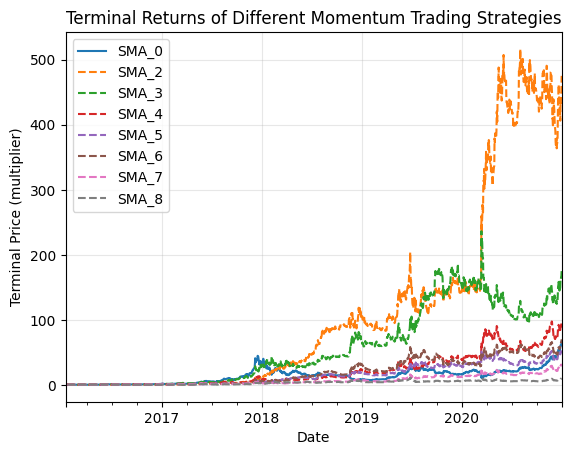

In [ ]:
for strategy, sma, linestyle in zip(momentum_strategies,
                                    [0,2,3,4,5,6,7,8],
                                    ['-', '--', '--', '--', '--', '--', '--', '--']):
    np.exp(strategy.cumsum()).plot(kind='line', label=f"SMA_{sma}", linestyle=linestyle)

plt.legend()
plt.title('Terminal Returns of Different Momentum Trading Strategies')
plt.ylabel('Terminal Price (multiplier)')
plt.grid(alpha=.3)
plt.show()

In [ ]:
sma_2_momentum_strat_terminal_ret = m.terminal_return(momentum_strategies[1]) * 100

print(f"Terminal return for momentum strategy using a 2-day rolling average: {sma_2_momentum_strat_terminal_ret:.2f} %")
print(f"Terminal return of asset: {cum_returns*100:.2f} %")

Terminal return for momentum strategy using a 2-day rolling average: 47405.42 %
Terminal return of asset: 6540.27 %


We can see that using a momentum strategy of 2 outperforms the return of the asset by nearly an order of magnitude!

In [ ]:
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,roc,atr,di+,di-
Date,,,,,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065,-0.206299,NaN,NaN,NaN
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938,-0.790656,NaN,NaN,NaN
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137,0.716265,NaN,NaN,NaN
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615,-0.261149,NaN,NaN,NaN


### Backtest

In [ ]:
from utils.backtest import MomentumBacktest

mombt = MomentumBacktest('BTC-USD',
                         '2021-01-01',
                         '2025-12-31',
                        #  trans_cost=0.0036,
                         amount=5000)

[*********************100%***********************]  1 of 1 completed


In [ ]:
creturns, cstrategy = mombt.strategy(momentum=2)

creturns.item(), cstrategy.item()

(13487.6, 24653.93)

In [ ]:
crann, csann = mombt.get_annualized_return()
term, term_trend = mombt.get_terminal_return()
crann, csann, term, term_trend

(np.float64(0.22), np.float64(0.38), 1.7, 3.93)

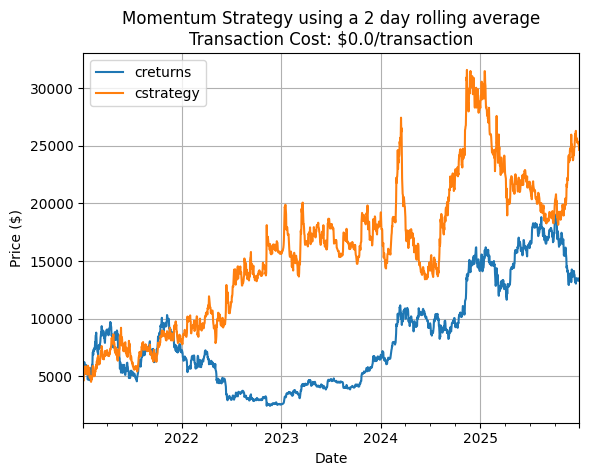

In [ ]:
mombt.plot_strategy()

In [ ]:
crets, cstrat = mombt.strategy(momentum=14)
crets, cstrat

(np.float64(12006.69), np.float64(24555.12))

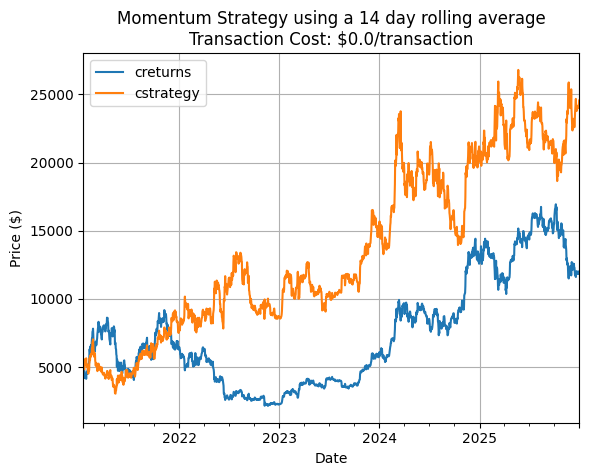

In [ ]:
mombt.plot_strategy()

In [ ]:
mombt_2 = MomentumBacktest(
    'BTC-USD',
    '2021-01-01',
    '2025-12-31',
    trans_cost=.36,
    amount=5000
)

[*********************100%***********************]  1 of 1 completed


In [ ]:
creturns_2, cstrategy_2 = mombt_2.strategy(momentum=2)

creturns_2.item(), cstrategy_2.item()

(13487.6, 23569.09)

In [ ]:
crann, csann = mombt_2.get_annualized_return()
term, term_trend = mombt_2.get_terminal_return()
crann, csann, term, term_trend

(np.float64(0.22), np.float64(0.36), 1.7, 3.71)

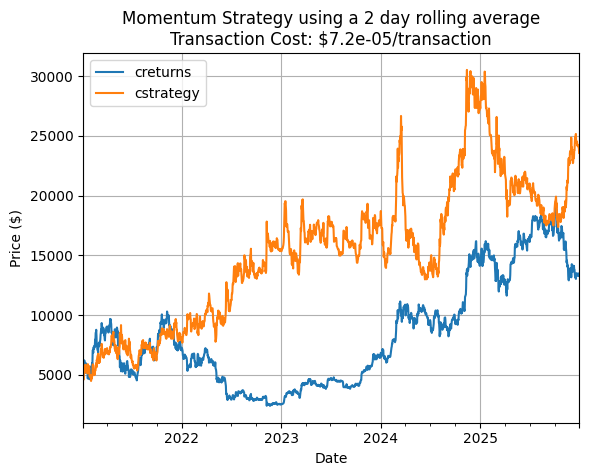

In [ ]:
mombt_2.plot_strategy()

In [ ]:
mombt_3 = MomentumBacktest('BTC-USD', '2012-01-01', '2015-07-25', amount=5000)
creturns_2015, cstrat_2015 = mombt_3.strategy(momentum=2)
creturns_2015, cstrat_2015

[*********************100%***********************]  1 of 1 completed


(np.float64(3650.97), np.float64(7030.24))

In [ ]:
crann, csann = mombt_3.get_annualized_return()
crann, csann

(np.float64(-0.31), np.float64(0.5))

In [ ]:
mombt_3 = MomentumBacktest('BTC-USD', '2012-01-01', '2015-07-25', trans_cost=.36, amount=5000)
creturns_2015, cstrat_2015 = mombt_3.strategy(momentum=2)
creturns_2015, cstrat_2015

[*********************100%***********************]  1 of 1 completed


(np.float64(3650.97), np.float64(6974.28))

In [ ]:
crann, csann = mombt_3.get_annualized_return()
crann, csann

(np.float64(-0.31), np.float64(0.48))

In [ ]:
mombt_4h = MomentumBacktest('BTC-USD', '2025-01-01', '2025-12-31', interval='4h', trans_cost=0.0, amount=5000)
creturns_2015, cstrat_2015 = mombt_4h.strategy(momentum=2)
creturns_2015, cstrat_2015

[*********************100%***********************]  1 of 1 completed


(np.float64(4740.32), np.float64(4518.28))

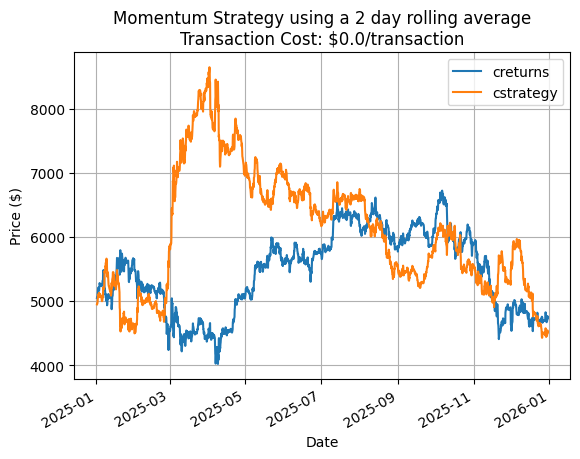

In [ ]:
mombt_4h.plot_strategy()

In [ ]:
mombt_4h = MomentumBacktest('BTC-USD', '2025-01-01', '2025-12-31', interval='4h', trans_cost=.36, amount=5000)
creturns_2015, cstrat_2015 = mombt_4h.strategy(momentum=2)
creturns_2015, cstrat_2015

[*********************100%***********************]  1 of 1 completed


(np.float64(4740.32), np.float64(4281.07))

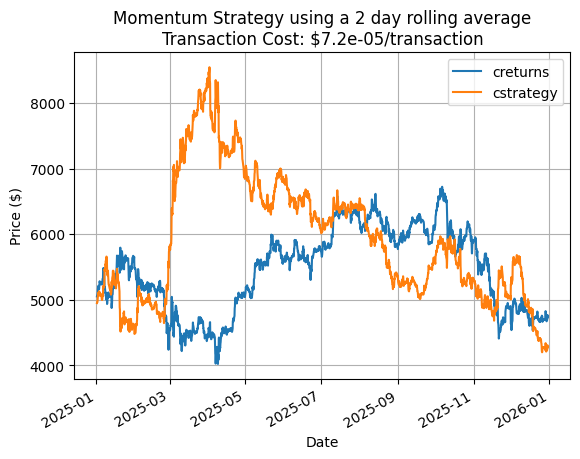

In [ ]:
mombt_4h.plot_strategy()